# Var class plus activation function

In [1]:
from rich import print

In [2]:
# Copy and pasted from https://github.com/rasmusbergpalm/nanograd/blob/3a1bf9e9e724da813bfccf91a6f309abdade9f39/nanograd.py


from math import exp, log

class Var:
    """
    A variable which holds a float and enables gradient computations.
    """

    def __init__(self, val: float, grad_fn=lambda: []):
        assert type(val) == float #verify whether value of Var is a float variable
        self.v = val
        self.grad_fn = grad_fn 
        self.grad = 0.0

    def backprop(self, bp):
        self.grad += bp 
        for input, grad in self.grad_fn():
            input.backprop(grad * bp)

    def backward(self):
        self.backprop(1.0)
        
    ## When you use a + b and a is an instance of a class that implements __add__, Python calls a.__add__(b).
    def __add__(self: 'Var', other: 'Var') -> 'Var': #self is a instance of Var class, by doing that return a variable from Var class
        return Var(self.v + other.v, lambda: [(self, 1.0), (other, 1.0)]) #return a list of tuples that stored in the new Var variable

    def __mul__(self: 'Var', other: 'Var') -> 'Var': ##"___x___" is to define behavior of operator for custom objects
        return Var(self.v * other.v, lambda: [(self, other.v), (other, self.v)])

    def __pow__(self, power):
        assert type(power) in {float, int}, "power must be float or int"
        return Var(self.v ** power, lambda: [(self, power * self.v ** (power - 1))])

    def __neg__(self: 'Var') -> 'Var': #use definited "__mul__" as grad_fn
        return Var(-1.0) * self

    def __sub__(self: 'Var', other: 'Var') -> 'Var': #use definited  "__add__" as grad_fn
        return self + (-other)

    def __truediv__(self: 'Var', other: 'Var') -> 'Var': #because self and other connect with "*", it return with "__mul__"
        return self * other ** -1
    
    def exp(self):
        return Var(exp(self.v), lambda: [(self, exp(self.v))])
    
    def log(self):
        return Var(log(self.v), lambda: [(self, self.v ** -1)])
    
    def __repr__(self): 
        return "Var(v=%.4f, grad=%.4f)" % (self.v, self.grad)

    def relu(self):
        return Var(self.v if self.v > 0.0 else 0.0, lambda: [(self, 1.0 if self.v > 0.0 else 0.0)])
    
    def identity(self):
        return Var(self.v,lambda: [(self, 1.0)])
        
    def tanh(self):
        def tanh_func(x):
            return (exp(x) - exp(-x)) / (exp(x) + exp(-x))
        value = tanh_func(self.v)
        return Var(value, lambda: [(self, 1.0 - value ** 2)])

    def sigmoid(self):
        def sig_func(x):
            return 1.0 / (1.0 + exp(-x))
        value = sig_func(self.v)
        return Var(value, lambda: [(self, value * (1 - value))])
        


# Create train,validation,test dataset

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def data_generator(noise=0.1, n_samples=300, D1=True):
    # Create covariates and response variable
    if D1:
        X = np.linspace(-3, 3, num=n_samples).reshape(-1,1) # 1-D
        np.random.shuffle(X)
        y = np.random.normal((0.5*np.sin(X[:,0]*3) + X[:,0]), noise) # 1-D with trend
    else:
        X = np.random.multivariate_normal(np.zeros(3), noise*np.eye(3), size = n_samples) # 3-D
        np.random.shuffle(X)
        y = np.sin(X[:,0]) - 5*(X[:,1]**2) + 0.5*X[:,2] # 3-D

    # Stack them together vertically to split data set
    data_set = np.vstack((X.T,y)).T #the last column contain y and the rest columns are all x in different dimensions.
    
    #axis=0, split along the rows
    train, validation, test = np.split(data_set, [int(0.35*n_samples), int(0.7*n_samples)], axis=0)
    

    # Standardization of the data, remember we do the standardization with the training set mean and standard deviation
    train_mu = np.mean(train, axis=0) #axis=0, do to every row == each column's all the data's mean
    train_sigma = np.std(train, axis=0)

    train = (train-train_mu)/train_sigma
    validation = (validation-train_mu)/train_sigma
    test = (test-train_mu)/train_sigma

    x_train, x_validation, x_test = train[:,:-1], validation[:,:-1], test[:,:-1]
    y_train, y_validation, y_test = train[:,-1], validation[:,-1], test[:,-1]

    return x_train, y_train,  x_validation, y_validation, x_test, y_test

D1 = False
x_train, y_train,  x_validation, y_validation, x_test, y_test = data_generator(noise=0.5, D1=D1)

## numpy array to var and var to numpy array

In [4]:
def Var_to_nparray(x):
  y = np.zeros((len(x),len(x[0])))
  for i in range(len(x)):
    for j in range(len(x[0])):
      y[i,j] = x[i][j].v
  return y

def nparray_to_Var(x):
  if x.ndim==1:
    y = [[Var(float(x[i]))] for i in range(x.shape[0])] # always work with list of list
  else:
    y = [[Var(float(x[i,j])) for j in range(x.shape[1])] for i in range(x.shape[0])]
  return y

In [5]:
# convert from nparray to Var
def nparray_to_Var(x):
  if x.ndim==1:
    y = [[Var(float(x[i]))] for i in range(x.shape[0])] # always work with list of list
  else:
    y = [[Var(float(x[i,j])) for j in range(x.shape[1])] for i in range(x.shape[0])]
  return y

x_train = nparray_to_Var(x_train)
y_train = nparray_to_Var(y_train)
x_validation = nparray_to_Var(x_validation)
y_validation = nparray_to_Var(y_validation)
x_test = nparray_to_Var(x_test)
y_test = nparray_to_Var(y_test)


# Initializer Class

In [6]:
class Initializer:

  def init_weights(self, n_in, n_out):
    raise NotImplementedError

  def init_bias(self, n_out):
    raise NotImplementedError

import random

class NormalInitializer(Initializer):

  def __init__(self, mean=0, std=0.1):
    self.mean = mean
    self.std = std
   
  ##number of input and number of output 
  def init_weights(self, n_in, n_out):
    return [[Var(random.gauss(self.mean, self.std)) for _ in range(n_out)] for _ in range(n_in)]

  def init_bias(self, n_out):
    return [Var(0.0) for _ in range(n_out)]
  
  
class ConstantInitializer(Initializer):

  def __init__(self, weight=1.0, bias=0.0):
    self.weight = weight
    self.bias = bias

  def init_weights(self, n_in, n_out):
    return [[Var(self.weight) for _ in range(n_out)] for _ in range(n_in)]

  def init_bias(self, n_out):
    return [Var(self.bias) for _ in range(n_out)]

# Dense layer class

In [7]:

from typing import Sequence
import inspect

class DenseLayer:
    def __init__(self, n_in: int, n_out: int, act_fn, initializer = NormalInitializer()):
        self.weights = initializer.init_weights(n_in, n_out)
        self.bias = initializer.init_bias(n_out)
        self.act_fn = act_fn

    # def __repr__(self):
    #     return 'Weights: ' + repr(self.weights) + ' Biases: ' + repr(self.bias)
    
# -> Sequence[Var] is the type-hint in python to indicate the return type 
    def parameters(self) -> Sequence[Var]: 
      params = []
      for r in self.weights:
        params += r

      return params + self.bias
    
    def __repr__(self):
        weight_info = "[" + ", ".join([str(weight) for weight in self.weights[0]]) + "]"
        bias_info = "[" + ", ".join([str(bias) for bias in self.bias]) + "]"
        method_info = inspect.getsource(self.act_fn).strip().split(":")[1].strip()
        return f"DenseLayer(weights={weight_info}, bias={bias_info},act_fun={method_info})" 

    def forward(self, single_input: Sequence[Var]) -> Sequence[Var]:
        # self.weights is a matrix with dimension n_in x n_out. We check that the dimensionality of the input
        # to the current layer matches the number of nodes in the current layer
        assert len(self.weights) == len(single_input), "weights and single_input must match in first dimension"
        weights = self.weights
        out = []
        # For some given data point single_input, we now want to calculate the resulting value in each node in the current layer
        # We therefore loop over the (number of) nodes in the current layer:
        #for each batch: is j, 
        for j in range(len(weights[0])):
            # Initialize the node value depending on its corresponding parameters.
            node = self.bias[j]
            # We now finish the linear transformation corresponding to the parameters of the currently considered node.
            for i in range(len(single_input)):
                node += self.weights[i][j] * single_input[i]
            node = self.act_fn(node)
            out.append(node)

        return out

### Two more weight initialization method by He and gault

In [8]:
import math
## Glorot
def DenseLayer_Glorot_tanh(n_in: int, n_out: int):
  std = math.sqrt(2/(n_in+n_out)) # <- replace with proper initialization
  return DenseLayer(n_in, n_out, lambda x: x.tanh(), initializer = NormalInitializer(std=std))

## He
def DenseLayer_He_relu(n_in: int, n_out: int):
  std = math.sqrt(2/n_in) # <- replace with proper initialization
  return DenseLayer(n_in, n_out, lambda x: x.relu(), initializer = NormalInitializer(std=std))

# Method in training and validation

#### Forward pass

In [9]:
def forward(input, network):

  def forward_single(x, network):
    for layer in network:
        x = layer.forward(x)
    return x

  output = [forward_single(input[n], network) for n in range(len(input))]
  return output

#### Parameters update

In [10]:
def parameters(network):
  params = []
  for layer in range(len(network)):
    params += network[layer].parameters() ##parameters get weight and bias
  return params

def update_parameters(params, learning_rate=0.01):
  for p in params:
    p.v -= learning_rate*p.grad #own weight.v change with own weight.grad

def zero_gradients(params):
  for p in params:
    p.grad = 0.0

#### Squared loss

In [11]:
def squared_loss(t, y):

  assert len(t) == len(y)# add check that sizes agree
  
  def squared_loss_single(t, y):
    Loss = Var(0.0)
    for i in range(len(t)): # sum over outputs
      Loss += (t[i]-y[i]) ** 2
    return Loss

  Loss = Var(0.0)
  for n in range(len(t)): # sum over training data
    Loss += squared_loss_single(t[n],y[n])
  return Loss


#### training before, we Copy all the x_train,y_train,y_validation,x_validation to not damage original data

In [12]:
import copy

x_train_copy = copy.deepcopy(x_train)
y_train_copy = copy.deepcopy(y_train)
x_validation_copy = copy.deepcopy(x_validation)
y_validation_copy = copy.deepcopy(y_validation)

# # Initialize an arbitrary neural network
# NN = [
#     DenseLayer(1, 8, lambda x: x.relu()),
#     DenseLayer(8, 1, lambda x: x.identity())
# ]

#Recommended hyper-parameters for 3-D:
NN = [
   DenseLayer(3, 16, lambda x: x.relu()),
   DenseLayer(16, 1, lambda x: x.identity())
]


### Notice that, when we switch from tanh to relu activation, we decrease the learning rate. This is due the stability of the gradients
## of the activation functions.

# Initialize training hyperparameters
EPOCHS = 200
LEARN_R = 2e-3

In [13]:
# loss_test = squared_loss(y_train_copy, forward(x_train_copy, NN));print(loss_test)
# print(NN[0])
# loss_test.backward()
# print(loss_test)
# print(NN[0])
# update_parameters(parameters(NN), LEARN_R)
# print(NN[0])
# zero_gradients(parameters(NN))
# print(NN[0])
# print(squared_loss(y_train_copy, forward(x_train_copy, NN)))

In [14]:
train_loss = []
val_loss = []

for e in range(EPOCHS):

    # Forward pass and loss computation
    Loss = squared_loss(y_train_copy, forward(x_train_copy, NN))
  
    # Backward pass
    Loss.backward()

    # gradient descent update
    update_parameters(parameters(NN), LEARN_R)
    zero_gradients(parameters(NN))

    # Training loss
    train_loss.append(Loss.v)

    # Validation
    Loss_validation = squared_loss(y_validation_copy, forward(x_validation_copy, NN))
    val_loss.append(Loss_validation.v)

    if e%10==0:
        print("{:4d}".format(e),
              "({:5.2f}%)".format(e/EPOCHS*100),
              "Train loss: {:4.3f} \t Validation loss: {:4.3f}".format(train_loss[-1], val_loss[-1]))
        


0 ( 0.00%) Train loss: 113.685        Validation loss: 123.702

10 ( 5.00%) Train loss: 56.213         Validation loss: 81.877

20 (10.00%) Train loss: 31.723         Validation loss: 54.264

30 (15.00%) Train loss: 16.745         Validation loss: 30.707

40 (20.00%) Train loss: 9.122          Validation loss: 18.253

...

150 (75.00%) Train loss: 1.790          Validation loss: 5.300

160 (80.00%) Train loss: 1.588          Validation loss: 4.940

170 (85.00%) Train loss: 1.395          Validation loss: 4.599

180 (90.00%) Train loss: 1.233          Validation loss: 4.255

190 (95.00%) Train loss: 1.108          Validation loss: 3.979

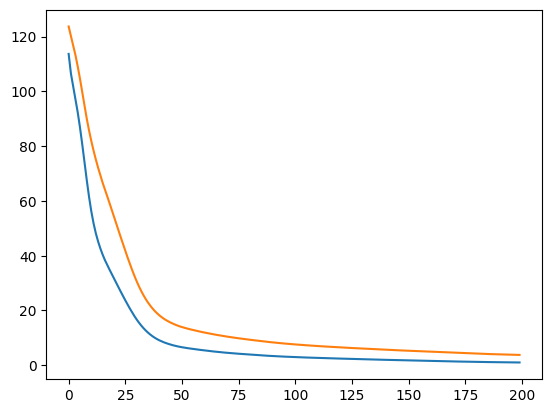

In [15]:
plt.plot(range(len(train_loss)), train_loss);
plt.plot(range(len(val_loss)), val_loss);

<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_13307/2220695506.py:7: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel("$\hat{y}$");


Test loss:  20.205

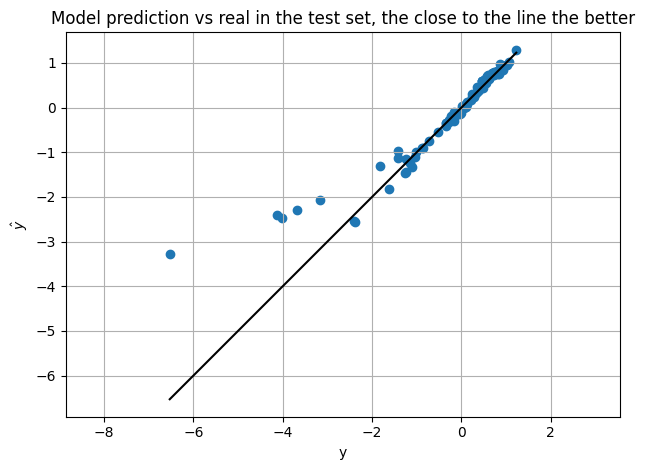

In [16]:
output_test = forward(x_test, NN)

y_test_np = Var_to_nparray(y_test)
plt.scatter(y_test_np, Var_to_nparray(output_test));
plt.plot([np.min(y_test_np), np.max(y_test_np)], [np.min(y_test_np), np.max(y_test_np)], color='k');
plt.xlabel("y");
plt.ylabel("$\hat{y}$");
plt.title("Model prediction vs real in the test set, the close to the line the better")
plt.grid(True);
plt.axis('equal');
plt.tight_layout();

Loss_test = squared_loss(y_test, forward(x_test, NN))

print("Test loss:  {:4.3f}".format(Loss_test.v))

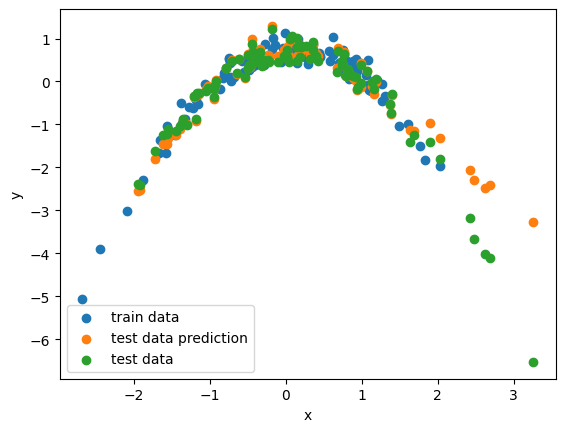

In [20]:
x_test_np = Var_to_nparray(x_test)
x_train_np = Var_to_nparray(x_train)
y_train_np = Var_to_nparray(y_train)
if D1:
    plt.scatter(x_train_np, y_train_np, label="train data");
    plt.scatter(x_test_np, Var_to_nparray(output_test), label="test prediction");
    plt.scatter(x_test_np, y_test_np, label="test data");
    plt.legend();
    plt.xlabel("x");
    plt.ylabel("y");
else:
    plt.scatter(x_train_np[:,1], y_train_np, label="train data");
    plt.scatter(x_test_np[:,1], Var_to_nparray(output_test), label="test data prediction");
    plt.scatter(x_test_np[:,1], y_test_np, label="test data");
    plt.legend();
    plt.xlabel("x");
    plt.ylabel("y");

# Right fitting

In [21]:
NN = [
   DenseLayer(3, 16, lambda x: x.relu()),
   DenseLayer(16, 1, lambda x: x.identity())
]


In [ ]:
# Initialize training hyperparameters
EPOCHS = 300
LEARN_R = 2e-3

#right fitting

train_loss = []
val_loss = []

for e in range(EPOCHS):

    # Forward pass and loss computation
    Loss = squared_loss(y_train_copy, forward(x_train_copy, NN))

    # Backward pass
    Loss.backward()

    # gradient descent update
    update_parameters(parameters(NN), LEARN_R)
    zero_gradients(parameters(NN))

    # Training loss
    train_loss.append(Loss.v)

    # Validation
    Loss_validation = squared_loss(y_validation_copy, forward(x_validation_copy, NN))
    val_loss.append(Loss_validation.v)

    if e%10==0:
        print("{:4d}".format(e),
              "({:5.2f}%)".format(e/EPOCHS*100),
              "Train loss: {:4.3f} \t Validation loss: {:4.3f}".format(train_loss[-1], val_loss[-1]))



In [ ]:
plt.plot(range(len(train_loss)), train_loss);
plt.plot(range(len(val_loss)), val_loss);

In [ ]:
output_test = forward(x_test, NN)

In [ ]:
y_test_np = Var_to_nparray(y_test)
plt.scatter(y_test_np, Var_to_nparray(output_test));
plt.plot([np.min(y_test_np), np.max(y_test_np)], [np.min(y_test_np), np.max(y_test_np)], color='k');
plt.xlabel("y");
plt.ylabel("$\hat{y}$");
plt.title("Model prediction vs real in the test set, the close to the line the better")
plt.grid(True);
plt.axis('equal');
plt.tight_layout();

Loss_test = squared_loss(y_test, forward(x_test, NN))

print("Test loss:  {:4.3f}".format(Loss_test.v))

In [ ]:
x_test_np = Var_to_nparray(x_test)
x_train_np = Var_to_nparray(x_train)
y_train_np = Var_to_nparray(y_train)
if D1:
    plt.scatter(x_train_np, y_train_np, label="train data");
    plt.scatter(x_test_np, Var_to_nparray(output_test), label="test prediction");
    plt.scatter(x_test_np, y_test_np, label="test data");
    plt.legend();
    plt.xlabel("x");
    plt.ylabel("y");
else:
    plt.scatter(x_train_np[:,1], y_train_np, label="train data");
    plt.scatter(x_test_np[:,1], Var_to_nparray(output_test), label="test data prediction");
    plt.scatter(x_test_np[:,1], y_test_np, label="test data");
    plt.legend();
    plt.xlabel("x");
    plt.ylabel("y");

# Overfitting

In [25]:
import copy

x_train_copy = copy.deepcopy(x_train)
y_train_copy = copy.deepcopy(y_train)
x_validation_copy = copy.deepcopy(x_validation)
y_validation_copy = copy.deepcopy(y_validation)

In [26]:
NN = [
   DenseLayer(3, 16, lambda x: x.relu()),
   DenseLayer(16, 1, lambda x: x.identity())
]


In [27]:
#overfitting
# Initialize training hyperparameters
EPOCHS = 200
LEARN_R = e-3


train_loss = []
val_loss = []

for e in range(EPOCHS):

    # Forward pass and loss computation
    Loss = squared_loss(y_train_copy, forward(x_train_copy, NN))

    # Backward pass
    Loss.backward()

    # gradient descent update
    update_parameters(parameters(NN), LEARN_R)
    zero_gradients(parameters(NN))

    # Training loss
    train_loss.append(Loss.v)

    # Validation
    Loss_validation = squared_loss(y_validation_copy, forward(x_validation_copy, NN))
    val_loss.append(Loss_validation.v)

    if e%10==0:
        print("{:4d}".format(e),
              "({:5.2f}%)".format(e/EPOCHS*100),
              "Train loss: {:4.3f} \t Validation loss: {:4.3f}".format(train_loss[-1], val_loss[-1]))



0 ( 0.00%) Train loss: 104.981        Validation loss: 121.689

10 ( 5.00%) Train loss: 104.981        Validation loss: 121.689

20 (10.00%) Train loss: 104.981        Validation loss: 121.689

30 (15.00%) Train loss: 104.981        Validation loss: 121.689

40 (20.00%) Train loss: 104.981        Validation loss: 121.689

...

150 (75.00%) Train loss: 104.981        Validation loss: 121.689

160 (80.00%) Train loss: 104.981        Validation loss: 121.689

170 (85.00%) Train loss: 104.981        Validation loss: 121.689

180 (90.00%) Train loss: 104.981        Validation loss: 121.689

190 (95.00%) Train loss: 104.981        Validation loss: 121.689

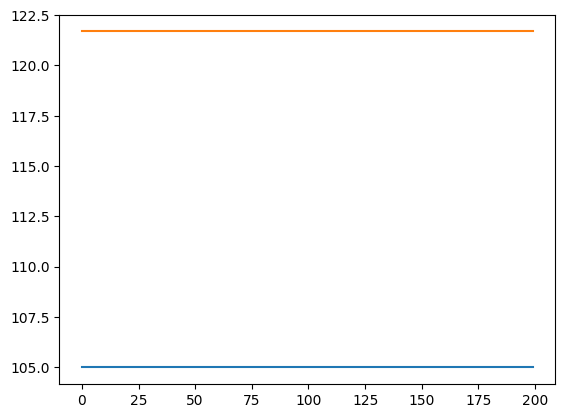

In [28]:
plt.plot(range(len(train_loss)), train_loss);
plt.plot(range(len(val_loss)), val_loss);

In [ ]:
output_test = forward(x_test, NN)

In [ ]:
y_test_np = Var_to_nparray(y_test)
plt.scatter(y_test_np, Var_to_nparray(output_test));
plt.plot([np.min(y_test_np), np.max(y_test_np)], [np.min(y_test_np), np.max(y_test_np)], color='k');
plt.xlabel("y");
plt.ylabel("$\hat{y}$");
plt.title("Model prediction vs real in the test set, the close to the line the better")
plt.grid(True);
plt.axis('equal');
plt.tight_layout();

Loss_test = squared_loss(y_test, forward(x_test, NN))

print("Test loss:  {:4.3f}".format(Loss_test.v))

In [ ]:
x_test_np = Var_to_nparray(x_test)
x_train_np = Var_to_nparray(x_train)
y_train_np = Var_to_nparray(y_train)
if D1:
    plt.scatter(x_train_np, y_train_np, label="train data");
    plt.scatter(x_test_np, Var_to_nparray(output_test), label="test prediction");
    plt.scatter(x_test_np, y_test_np, label="test data");
    plt.legend();
    plt.xlabel("x");
    plt.ylabel("y");
else:
    plt.scatter(x_train_np[:,1], y_train_np, label="train data");
    plt.scatter(x_test_np[:,1], Var_to_nparray(output_test), label="test data prediction");
    plt.scatter(x_test_np[:,1], y_test_np, label="test data");
    plt.legend();
    plt.xlabel("x");
    plt.ylabel("y");

# Underfitting

In [ ]:
#underfitting
# Initialize training hyperparameters
EPOCHS = 200
LEARN_R = 2e-3

train_loss = []
val_loss = []

for e in range(EPOCHS):

    # Forward pass and loss computation
    Loss = squared_loss(y_train_copy, forward(x_train_copy, NN))

    # Backward pass
    Loss.backward()

    # gradient descent update
    update_parameters(parameters(NN), LEARN_R)
    zero_gradients(parameters(NN))

    # Training loss
    train_loss.append(Loss.v)

    # Validation
    Loss_validation = squared_loss(y_validation_copy, forward(x_validation_copy, NN))
    val_loss.append(Loss_validation.v)

    if e%10==0:
        print("{:4d}".format(e),
              "({:5.2f}%)".format(e/EPOCHS*100),
              "Train loss: {:4.3f} \t Validation loss: {:4.3f}".format(train_loss[-1], val_loss[-1]))



In [ ]:
plt.plot(range(len(train_loss)), train_loss);
plt.plot(range(len(val_loss)), val_loss);

In [ ]:
output_test = forward(x_test, NN)

In [ ]:
y_test_np = Var_to_nparray(y_test)
plt.scatter(y_test_np, Var_to_nparray(output_test));
plt.plot([np.min(y_test_np), np.max(y_test_np)], [np.min(y_test_np), np.max(y_test_np)], color='k');
plt.xlabel("y");
plt.ylabel("$\hat{y}$");
plt.title("Model prediction vs real in the test set, the close to the line the better")
plt.grid(True);
plt.axis('equal');
plt.tight_layout();

Loss_test = squared_loss(y_test, forward(x_test, NN))

print("Test loss:  {:4.3f}".format(Loss_test.v))

In [ ]:
x_test_np = Var_to_nparray(x_test)
x_train_np = Var_to_nparray(x_train)
y_train_np = Var_to_nparray(y_train)
if D1:
    plt.scatter(x_train_np, y_train_np, label="train data");
    plt.scatter(x_test_np, Var_to_nparray(output_test), label="test prediction");
    plt.scatter(x_test_np, y_test_np, label="test data");
    plt.legend();
    plt.xlabel("x");
    plt.ylabel("y");
else:
    plt.scatter(x_train_np[:,1], y_train_np, label="train data");
    plt.scatter(x_test_np[:,1], Var_to_nparray(output_test), label="test data prediction");
    plt.scatter(x_test_np[:,1], y_test_np, label="test data");
    plt.legend();
    plt.xlabel("x");
    plt.ylabel("y");